In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv('train.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.drop(columns=['Name','Cabin','PassengerId','Ticket'],inplace=True)

In [5]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [14]:
bins=[0,18,50,100]
label=['Child','Adult','Old']

In [15]:
df['Age_group']=pd.cut(df['Age'],bins=bins,labels=label)

<Axes: xlabel='Age_group'>

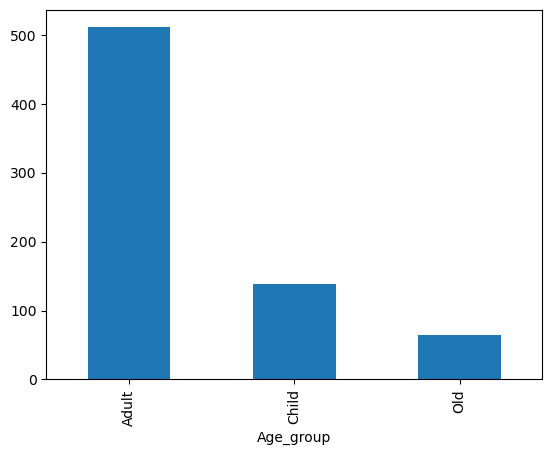

In [17]:
df['Age_group'].value_counts().plot(kind='bar')

In [20]:
df['Family']=df['SibSp']+df['Parch']+1

In [25]:
df['Family']

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: Family, Length: 891, dtype: int64

In [26]:
df['Is_alone']=(df['Family']==1).astype(int)

In [30]:
df[['SibSp', 'Parch', 'Family', 'Is_alone']].head(10)

,SibSp,Parch,Family,Is_alone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1
5,0,0,1,1
6,0,0,1,1
7,3,1,5,0
8,0,2,3,0
9,1,0,2,0


In [31]:
tips=sns.load_dataset('tips')

In [32]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [33]:
dummy_dates = ['2026-06-15', '2026-01-20', '2025-12-05'] * (len(df)//3) + ['2026-06-15'] * (len(df)%3)

In [39]:
# Create the date range first, then sample from it
date_range = pd.date_range('2024-01-01', '2025-01-01')

# Now sample 'len(df)' number of dates from that range
df['Dates'] = pd.to_datetime(np.random.choice(date_range, size=len(df)))

In [40]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Age_group,Family,Is_alone,Dates
0,0,3,male,22.0,1,0,7.2500,S,Adult,2,0,2024-05-22
1,1,1,female,38.0,1,0,71.2833,C,Adult,2,0,2024-07-28
2,1,3,female,26.0,0,0,7.9250,S,Adult,1,1,2024-09-03
3,1,1,female,35.0,1,0,53.1000,S,Adult,2,0,2024-05-08
4,0,3,male,35.0,0,0,8.0500,S,Adult,1,1,2024-10-04


In [41]:
df['year']=df['Dates'].dt.year
df['month']=df['Dates'].dt.month
df['day']=df['Dates'].dt.day
df['dayofweek']=df['Dates'].dt.dayofweek
df['quarter']=df['Dates'].dt.quarter

In [42]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Age_group,Family,Is_alone,Dates,year,month,day,dayofweek,quarter
0,0,3,male,22.0,1,0,7.2500,S,Adult,2,0,2024-05-22,2024,5,22,2,2
1,1,1,female,38.0,1,0,71.2833,C,Adult,2,0,2024-07-28,2024,7,28,6,3
2,1,3,female,26.0,0,0,7.9250,S,Adult,1,1,2024-09-03,2024,9,3,1,3
3,1,1,female,35.0,1,0,53.1000,S,Adult,2,0,2024-05-08,2024,5,8,2,2
4,0,3,male,35.0,0,0,8.0500,S,Adult,1,1,2024-10-04,2024,10,4,4,4
